# TP5 : Positionnement Multidimensionnel (MDS)

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA et la NMF. Le présent TP utilisant les résultats de ces dernier, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**), `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) et `NMF` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies. 

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [3]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [4]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io>
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va commencer par la définition progressive (par Monkey-Patching) d'une classe `MyMDS` implémentant l'algorithme de MDS donné dans la présentation.

In [6]:
class MyMDS:
    def __init__(self, n_components):
        self.n_components = n_components
        
        self.eigenvalues = None
        self.components = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

La première étape est de coder une fonction `distances(data)` construisant la matrice de distance d'une matrice de données `data`. Si $X$ est une matrice où chaque ligne est une donnée, la matrice $D$ de distances de $X$ est telles que $D_{ij} = d(X[i],X[j])$ pour tous $i,j$. Il serait par exemple possible d'utiliser la formule suivante :

- `np.linalg.norm(data.reshape((data.shape[0],1,data.shape[1])) - data.reshape((1,data.shape[0],data.shape[1]),axis=2)`

Néanmoins, si la matrice de données a 2535 lignes et 784 colonnes, la matrice intermédiaire utilisée dans ce calcul a $2535^2 \times 784$ entrées. Cela fait plus de 5 milliards. Cela rend le calcul infaisable (pour des raisons d'attribution de mémoire). 

Pour cette raison, il convient d'utiliser la formule d'Al-Kashi :
$$d(x,y)^2 = ||x||^2 + ||y||^2 - 2 \langle x,y \rangle$$

(Note : Il se peut que des erreurs d'approximation résultent en de minuscules nombres négatifs au lieu de 0. Cela empêche l'utilisation de la fonction `np.sqrt`. Il convient alors de remplacer ces erreurs négatives par des 0.)

In [7]:
## Écrivez votre code ici.
def distances(data):
    x=np.sum(data**2,axis=1)
    product=np.dot(data,data.T)
    sqqrt_D=x[np.newaxis,:]+x[:,np.newaxis]-2*product
    sqrt_pos=np.maximum(sqqrt_D,0)
    return np.sqrt(sqrt_pos)

## Exercice 2

Il s'agit maintenant de construire les fonctions qui formeront le corps de la classe `MDS`.

1. Construisez une fonction `double_centre(D)` qui reconstruit la matrice de Gram à partir d'une matrice de distances. 

In [8]:
## Écrivez votre code ici.
def double_centre(D):
    mean_row=np.mean(D**2,axis=1)
    mean_col=np.mean(D**2,axis=0)
    mean_tot=np.mean(D**2)
    B=-0.5*((D**2)-mean_row[:,np.newaxis]-mean_col+mean_tot)
    return B

2. On opère ensuite une décomposition spectrale pour récupérer les valeurs propres et ses vecteurs propres de la matrice de Gram. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petite à la plus grande,
- `top_eigenvectors` est la matrice où chacune des $n$ colonnes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [9]:
## Écrivez votre code ici.
def get_principal_components(comatrix, n_components): 
    eigenvalues,eigenvectors=np.linalg.eigh(comatrix)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    total = np.sum(eigenvalues)
    top_eigenvalues = eigenvalues[-n_components:]
    top_eigenvectors = eigenvectors[:, -n_components:]
    
    return top_eigenvalues, top_eigenvectors, total

## Exercice 3

Nous allons maintenant construire la classe par Monkey-Patching.

1. Construisez une fonction `fit_transform(self, data)` implémentant la totalité de l'algorithme du MDS à l'aide des fonctions précedemments définies. Cette fonction renvoie la matrice projetée et assigne `self.eigenvalues` et `self.components` (au format où chaque ligne est une composante).

In [11]:
## Écrivez votre code ici.
def fit_transfom(self,data):
    D=distances(data)
    B=double_centre(D)
    topegvalues,topevectors,total=get_principal_components(B,self.n_components)
    self.eigenvalues=topegvalues
    self.components=topevectors.T
    return  topevectors @ np.diag(np.sqrt(topegvalues))
MyMDS.fit_transform=fit_transfom



2. Vérifiez que la classe est bien implémentée en réalisant une MDS sur $X$ avec deux composantes. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**) coloré par nos labels (`y`). Faites la même chose avec une PCA à deux composantes. Les résultats devraient être les mêmes (à une rotation près). 

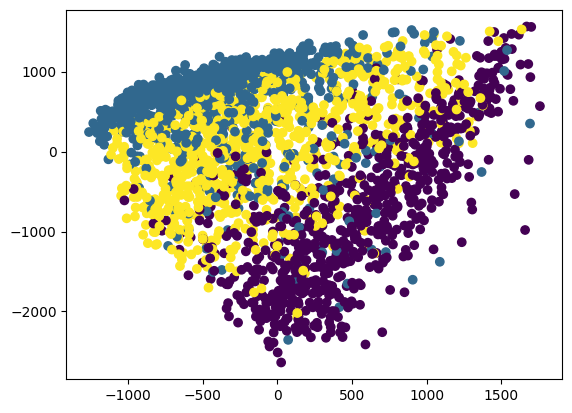

In [12]:
## Écrivez votre code ici pour le MDS.
mds=MyMDS(2)
X_mds=mds.fit_transform(X)
plt.scatter(X_mds[:,0],X_mds[:,1],c=y)

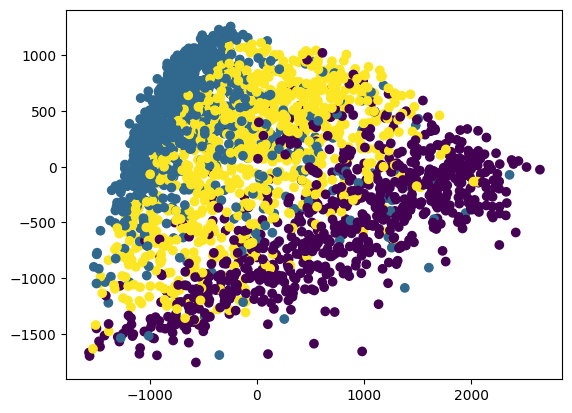

In [14]:
## Écrivez votre code ici pour la PCA.
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y)

## Exercice 4

Nous allons maintenant construire une classe `MyIsomap` implémentant l'algorithme Isomap présenté dans la présentation. Il va falloir faire une MDS sur une matrice de distances géodésiques approximées. Construisez la fonction `fit_transform(self, data)` qui retourne la matrice projetée après application de l'algorithme.

Utilisez la fonction `kneighbors_graph` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html)**) pour construire la matrice des distances des $k$ voisins les plus proches. Utilisez la fonction `shortest_path` (**[documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.shortest_path.html)**) pour implémenter l'algorithme de Djikstra.

In [19]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

class MyIsomap:
    def __init__(self, n_neighbors, n_components):
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.mds = MyMDS(n_components) 
        
    def fit_transform(self, X):
        ## Écrivez votre code ici.
        graph = kneighbors_graph(X, n_neighbors=self.n_neighbors, mode='distance')
        dist = shortest_path(graph, directed=False)
        B= double_centre(dist)
        
        top_eigenvalues, top_eigenvectors, total = get_principal_components( B, self.n_components )
        self.eigenvalues = top_eigenvalues
        self.components = top_eigenvectors.T
        
        
        return top_eigenvectors @ np.diag(np.sqrt(np.maximum(top_eigenvalues, 0)))
        
        

## Exercice 5

1. Appliquez Isomap (deux composantes) à nos données et visualisez les résultats dans un nuage de points colorés par nos labels. Que se passe t-il lorsque l'on fait varier le nombre de voisins ?


Faire varier le nombre de voisins modifie la connectivité du graphe : un $k$ trop petit fragmente les données en amas isolés, tandis qu'un $k$ trop grand crée des "court-circuits" entre des points éloignés, faisant converger Isomap vers un simple MDS linéaire.

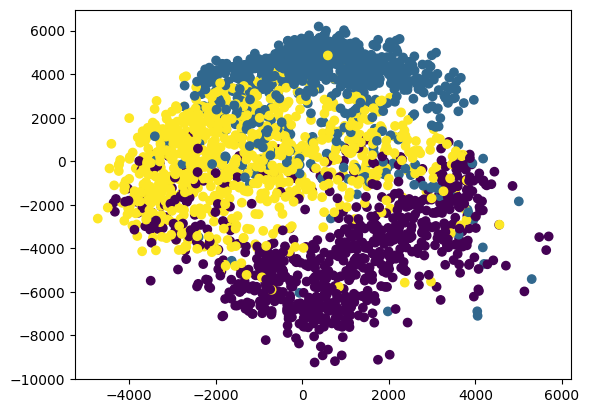

In [22]:
## Écrivez votre code ici.
isomap=MyIsomap(5,2)
X_mds=isomap.fit_transform(X)
plt.scatter(X_mds[:,0],X_mds[:,1],c=y)

Écrivez ici votre réponse.

2. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection Isomap de `X` en 2 dimensions, avec 3 clusters. Affichez la précision de ces labels. Pour quel nombre de voisins trouve t-on les meilleurs résultats ? Pourquoi ?

On trouve les meilleurs résultats pour un $k$ qui est juste assez grand pour assurer que le graphe est entièrement connecté, mais assez petit pour ne pas créer de raccourcis erronés entre les plis des données. C'est à ce point précis que le K-means pourra le mieux séparer les groupes, car les distances entre clusters seront maximisées par le "dépliage"

0.7992110453648915


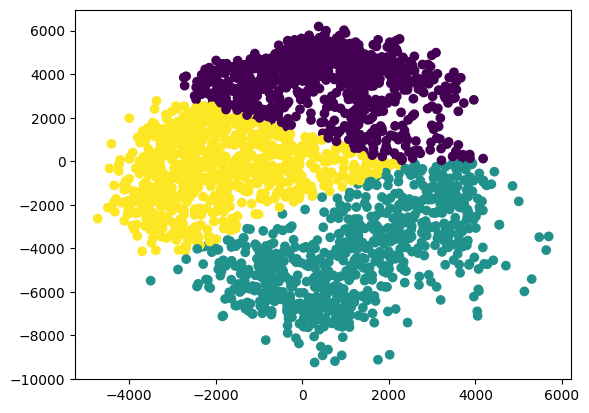

In [25]:
## Écrivez votre code ici.
cl=KMeans(3)
cl.fit(X_mds) 
print(accuracy(cl.labels_))
plt.scatter(X_mds[:,0],X_mds[:,1],c=cl.labels_)

Écrivez ici votre réponse.

## Exercice 5

On peut utiliser Isomap pour mieux visualiser la manière dont la NMF peut séparer les données. 

1. Réalisez une NMF sur $X$ avec 8 composantes. Utilisez la classe de `sklearn` avec la méthode d'initialisation `nndsvd` (pour de meilleurs résultats de convergence). Faites tourner un $3-$clustering sur la matrice projetée et affichez sa précision.

In [29]:
nmf=NMF(n_components=8,init='nndsvd',max_iter=1000)
X_nmf=nmf.fit_transform(X)
cl=KMeans(3)
cl.fit(X_nmf) 
print(accuracy(cl.labels_))

0.8694280078895463


2. Le résultat devrait être assez satisfaisant. Nous voulons maintenant visualisez la manière dont la séparation des données s'opére dans la NMF. Essayons d'abord de projeter en deux dimensions avec une méthode linéaire (PCA ou MDS). Visualisez le résultat avec un nuage de points colorés par nos labels `y`.

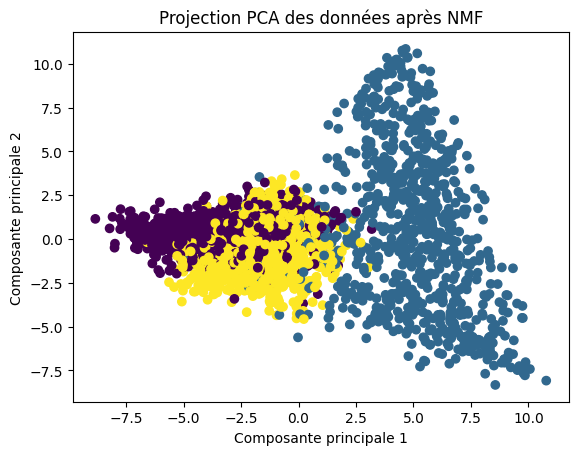

In [30]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_nmf)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA des données après NMF")
plt.show()

3. Faites la même chose avec Isomap avec 10 voisins.

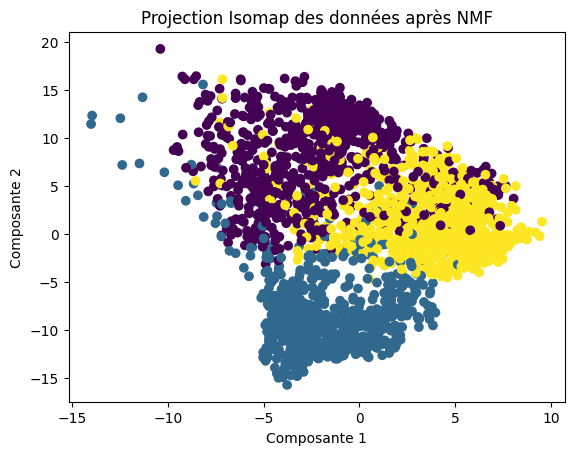

In [31]:
## Écrivez votre code ici.
isomap=MyIsomap(n_neighbors=10, n_components=2)
X_isomap=isomap.fit_transform(X_nmf)
plt.figure()
plt.scatter(X_isomap[:, 0], X_isomap[:, 1], c=y)
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Projection Isomap des données après NMF")
plt.show()


4. Faites varier le nombres de composantes de la NMF et le nombre de voisins dans l'Isomap. Interprétez les résultats.

La séparation des données repose sur un compromis : le nombre de composantes NMF doit être assez élevé pour capturer les détails des classes sans créer de bruit, tandis que le nombre de voisins Isomap doit être équilibré pour "déplier" la structure sans créer de faux raccourcis entre les groupes. On obtient les meilleurs résultats avec une dizaine de composantes et un voisinage intermédiaire, car c'est là que les amas de couleurs deviennent les plus denses et les mieux isolés visuellement